# Exploratory Data Analysis (EDA) - Cleaned Prices & Discount Dataset
## Comprehensive Analysis of Ethnic Dress Products
This notebook performs an in-depth exploratory data analysis on the cleaned prices and discount dataset containing ethnic dress products.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Inspect the Dataset

In [2]:
# Load the dataset
csv_path = r"c:\Users\malih\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\026DC700962774AA6E589A19EE5146E2B9DDEED6\transfers\2026-17\cleaned_prices_discount_dataset.csv"
df = pd.read_csv(csv_path)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names and Data Types:")
print(df.dtypes)
print(f"\nFirst 5 Rows:")
df.head()

DATASET OVERVIEW

Dataset Shape: 194 rows × 17 columns

Column Names and Data Types:
Name                   str
Brand                  str
Price              float64
Rating                 str
Reviews                str
Discount           float64
Length                 str
Neck                   str
Sleeve_Length          str
Sleeve_Style           str
Shape                  str
Sizes_Available        str
Color_Count          int64
Pocket                 str
Material_&_Care        str
Product_Link           str
Category               str
dtype: object

First 5 Rows:


,Name,Brand,Price,Rating,Reviews,Discount,Length,Neck,Sleeve_Length,Sleeve_Style,Shape,Sizes_Available,Color_Count,Pocket,Material_&_Care,Product_Link,Category
0,Women Floral Printed Pure Cotton A-Line Midi D...,Sangria,704.0,4.3 | 82 Ratings,82 Ratings,704.0,Midi,V-Neck,NaN,NaN,A-Line,"M, L, XL, XXL",4,No,Cotton,https://www.myntra.com/ethnic-dresses/sangria/...,Casual
1,Women Maternity Floral Printed Ethnic Dress,Vaidiki,676.0,5 | 5 Ratings,5 Ratings,676.0,Maxi,Round Neck,NaN,NaN,NaN,"5XL, 6XL, 7XL, 8XL",4,No,Viscose Rayon,https://www.myntra.com/ethnic-dresses/vaidiki/...,Traditional
2,Women Floral Thread Embroidered Ethnic Dress,Inddus,1596.0,4.2 | 61 Ratings,61 Ratings,1596.0,Maxi,V-Neck,NaN,NaN,NaN,"XS, S, M, L, XL",4,No,Net,https://www.myntra.com/ethnic-dresses/inddus/i...,Party Wear
3,Women Floral Printed Round Neck Pure Cotton Ma...,Henal,752.0,NaN,NaN,752.0,Maxi,Round Neck,Three-Quarter Sleeves,Regular Sleeves,NaN,"M, L, XL, XXL",4,No,Cotton,https://www.myntra.com/ethnic-dresses/henal/he...,Traditional
4,Embroidered Floral Ethnic Dresses,Angoshobha,3652.0,NaN,NaN,3652.0,Knee Length,Shirt Collar,Short Sleeves,NaN,A-Line,M,4,No,Cotton,https://www.myntra.com/ethnic-dresses/angoshob...,Party Wear


In [3]:
# Detailed dataset information
print("\n" + "=" * 80)
print("DETAILED DATASET INFO")
print("=" * 80)
df.info()
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DETAILED DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             194 non-null    str    
 1   Brand            194 non-null    str    
 2   Price            194 non-null    float64
 3   Rating           154 non-null    str    
 4   Reviews          154 non-null    str    
 5   Discount         194 non-null    float64
 6   Length           194 non-null    str    
 7   Neck             169 non-null    str    
 8   Sleeve_Length    99 non-null     str    
 9   Sleeve_Style     112 non-null    str    
 10  Shape            104 non-null    str    
 11  Sizes_Available  194 non-null    str    
 12  Color_Count      194 non-null    int64  
 13  Pocket           194 non-null    str    
 14  Material_&_Care  194 non-null    str    
 15  Product_Link     194 non-null    str    
 16  Category         194 non-null    str    
dtypes: f

## 3. Data Summary Statistics

In [4]:
print("=" * 80)
print("DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("=" * 80)
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe().T)

DESCRIPTIVE STATISTICS - NUMERICAL FEATURES
             count         mean          std    min    25%     50%      75%  \
Price        194.0  1929.902062  3107.055407  365.0  676.0  1165.0  1602.25   
Discount     194.0  1929.902062  3107.055407  365.0  676.0  1165.0  1602.25   
Color_Count  194.0     3.711340     0.454312    3.0    3.0     4.0     4.00   

                 max  
Price        18558.0  
Discount     18558.0  
Color_Count      4.0  


In [5]:
# Additional statistics
print("\n" + "=" * 80)
print("ADDITIONAL STATISTICS")
print("=" * 80)
print("\nSkewness (measure of asymmetry):")
print(df[numerical_cols].skew())
print("\nKurtosis (measure of tail heaviness):")
print(df[numerical_cols].kurtosis())


ADDITIONAL STATISTICS

Skewness (measure of asymmetry):
Price          4.374797
Discount       4.374797
Color_Count   -0.940067
dtype: float64

Kurtosis (measure of tail heaviness):
Price          20.056118
Discount       20.056118
Color_Count    -1.128011
dtype: float64


## 4. Missing Values Analysis

MISSING VALUES ANALYSIS
             Column  Missing_Count  Missing_Percentage
8     Sleeve_Length             95           48.969072
10            Shape             90           46.391753
9      Sleeve_Style             82           42.268041
3            Rating             40           20.618557
4           Reviews             40           20.618557
7              Neck             25           12.886598
0              Name              0            0.000000
1             Brand              0            0.000000
2             Price              0            0.000000
5          Discount              0            0.000000
6            Length              0            0.000000
11  Sizes_Available              0            0.000000
12      Color_Count              0            0.000000
13           Pocket              0            0.000000
14  Material_&_Care              0            0.000000
15     Product_Link              0            0.000000
16         Category              0       

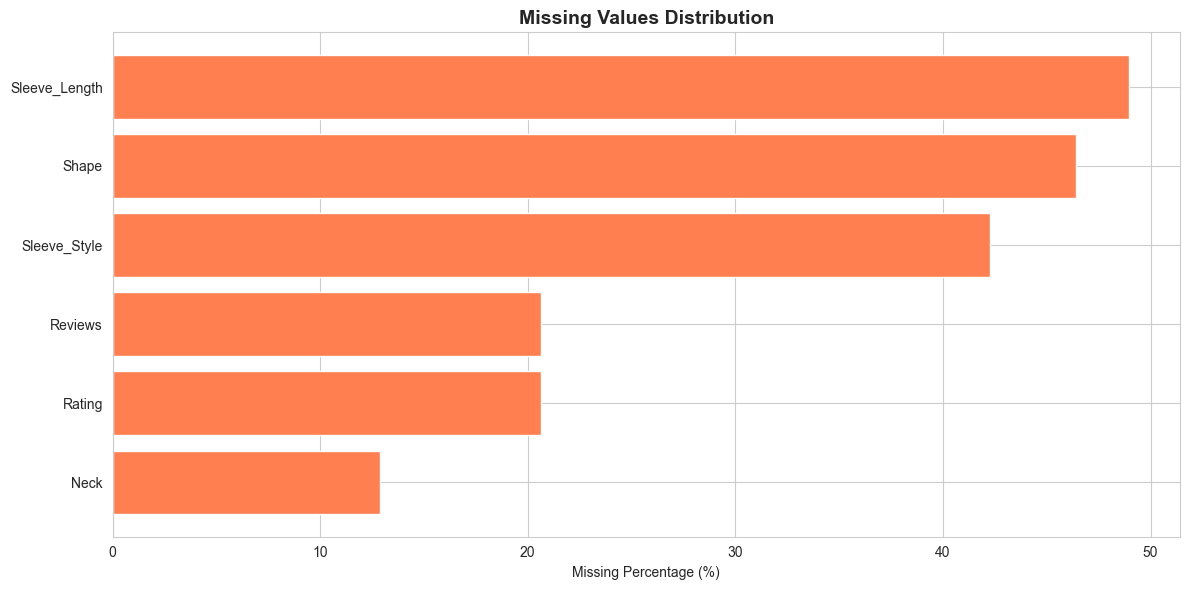

In [6]:
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percent.values
}).sort_values('Missing_Percentage', ascending=False)
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_df_sorted = missing_df[missing_df['Missing_Percentage'] > 0].sort_values('Missing_Percentage')
if len(missing_df_sorted) > 0:
    ax.barh(missing_df_sorted['Column'], missing_df_sorted['Missing_Percentage'], color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

## 5. Distribution Analysis

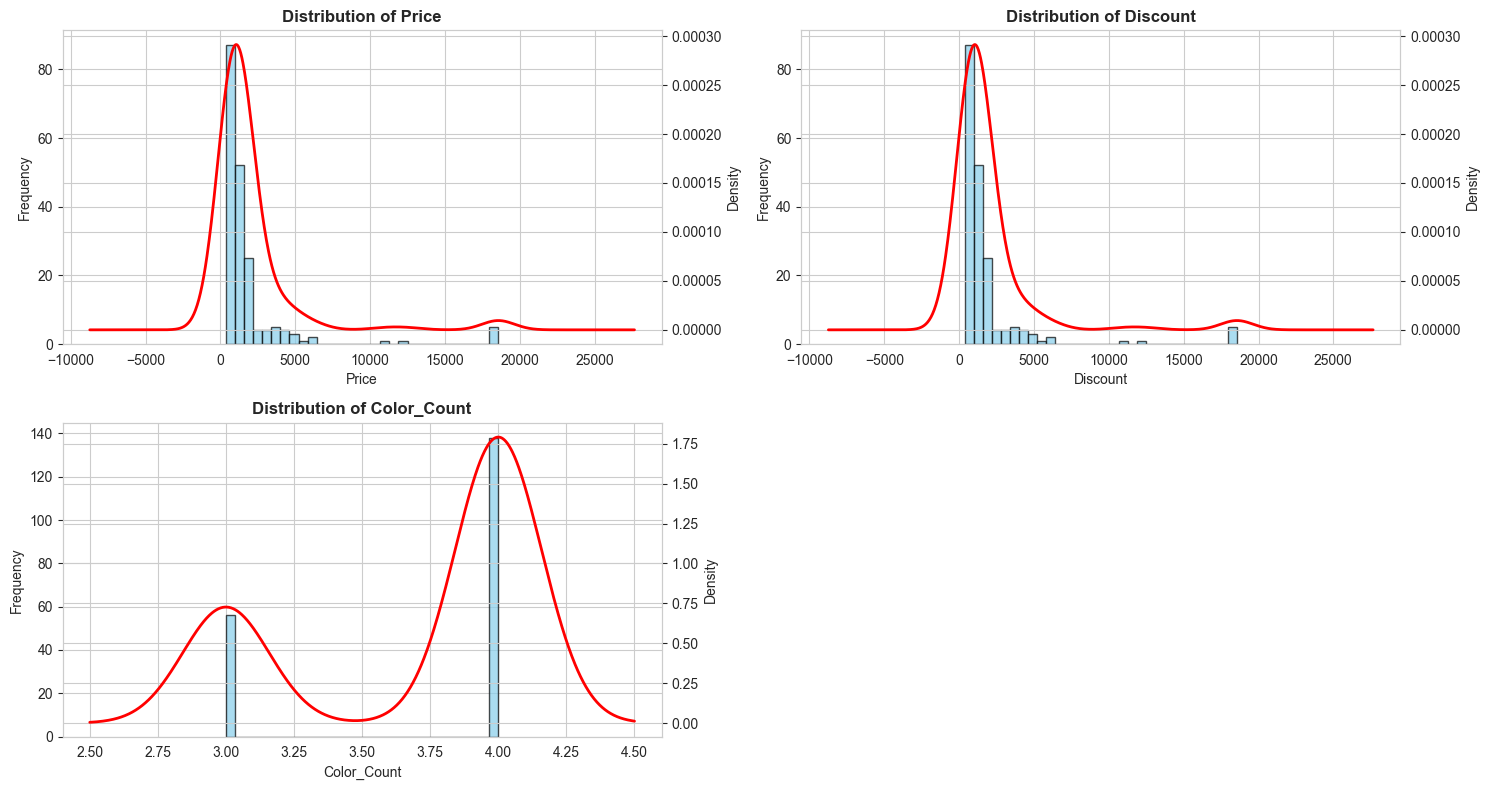

In [7]:
# Distribution analysis for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numerical_cols)
fig, axes = plt.subplots((n_cols + 1) // 2, 2, figsize=(15, 4 * ((n_cols + 1) // 2)))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add KDE plot on secondary axis
    ax2 = axes[idx].twinx()
    df[col].dropna().plot(kind='density', ax=ax2, color='red', linewidth=2)
    ax2.set_ylabel('Density')

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

CORRELATION MATRIX HEATMAP
Dataset Shape after preprocessing: (154, 8)
Numerical Columns: ['Price', 'Discount', 'Color_Count', 'Rating_Numeric', 'Reviews_Numeric', 'Sizes_Count', 'Price_Per_Size', 'Rating_Score']

Correlation Matrix:
                 Price  Discount  Color_Count  Rating_Numeric  \
Price            1.000     1.000        0.082          -0.014   
Discount         1.000     1.000        0.082          -0.014   
Color_Count      0.082     0.082        1.000          -0.166   
Rating_Numeric  -0.014    -0.014       -0.166           1.000   
Reviews_Numeric -0.048    -0.048       -0.157           0.106   
Sizes_Count     -0.198    -0.198       -0.133          -0.012   
Price_Per_Size   0.732     0.732        0.180          -0.074   
Rating_Score    -0.014    -0.014       -0.166           1.000   

                 Reviews_Numeric  Sizes_Count  Price_Per_Size  Rating_Score  
Price                     -0.048       -0.198           0.732        -0.014  
Discount                

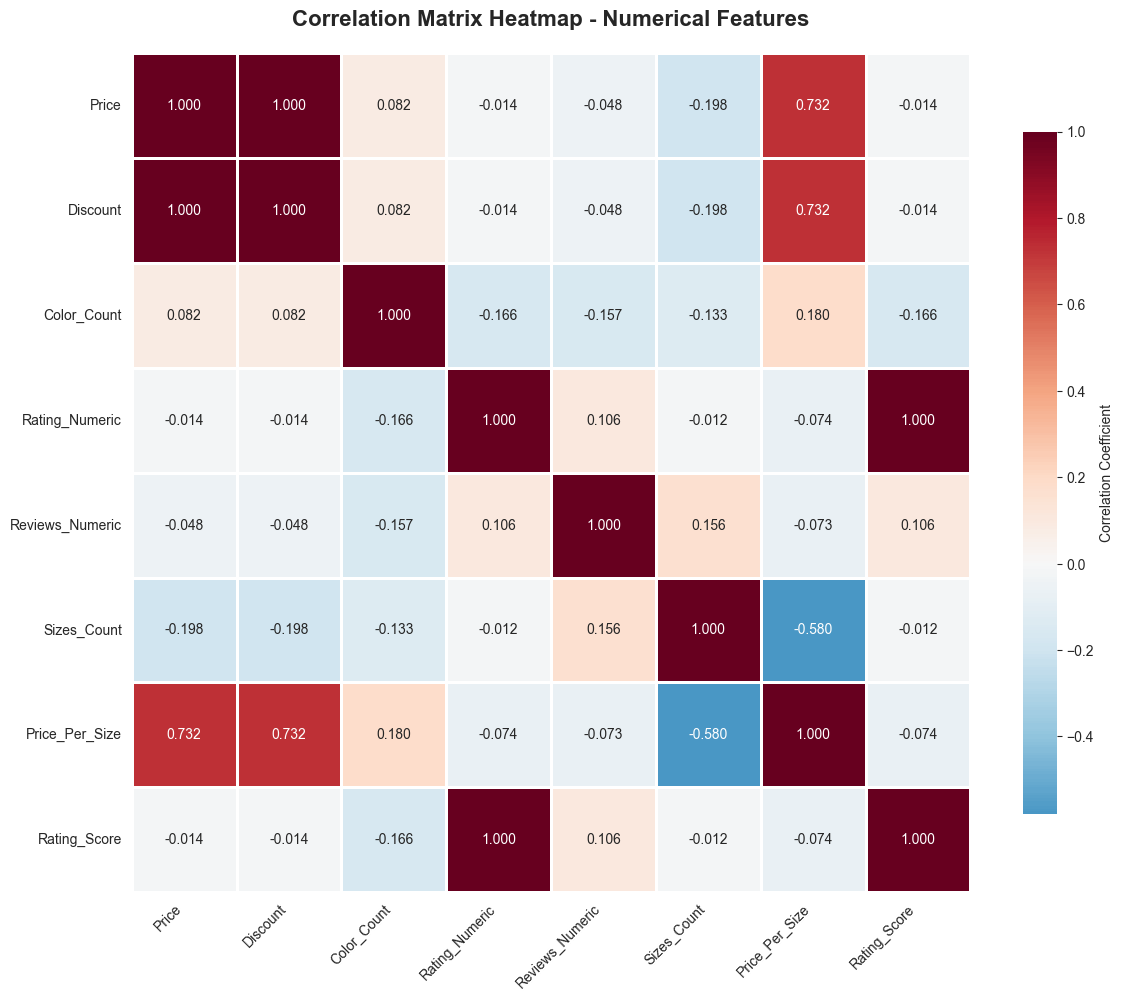


Correlation heatmap saved as 'correlation_heatmap.png'
Correlation matrix saved as 'correlation_matrix.csv'


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('cleaned_prices_discount_dataset.csv')

# Data Preprocessing - Convert columns to numeric where needed
# Price and Discount are already numeric, but we need to clean Rating
def extract_rating(rating_str):
    if pd.isna(rating_str):
        return np.nan
    try:
        # Extract numeric part before '|' if exists
        rating = str(rating_str).split('|')[0].strip()
        return float(rating)
    except:
        return np.nan

# Extract numeric rating
df['Rating_Numeric'] = df['Rating'].apply(extract_rating)

# Extract Reviews count (remove ' Ratings' or 'k' suffix)
def extract_reviews(reviews_str):
    if pd.isna(reviews_str):
        return np.nan
    try:
        reviews = str(reviews_str).replace(' Ratings', '').strip()
        if 'k' in reviews:
            return float(reviews.replace('k', '')) * 1000
        return float(reviews)
    except:
        return np.nan

df['Reviews_Numeric'] = df['Reviews'].apply(extract_reviews)

# Extract number of sizes available
def count_sizes(sizes_str):
    if pd.isna(sizes_str):
        return np.nan
    try:
        sizes = str(sizes_str).split(',')
        return len(sizes)
    except:
        return np.nan

df['Sizes_Count'] = df['Sizes_Available'].apply(count_sizes)

# Create price discounts (already have Price and Discount columns)
# Note: In your data, Price and Discount seem to be the same (no discount applied)
# Let's create an actual discount percentage column
df['Discount_Percentage'] = ((df['Price'] - df['Discount']) / df['Price'] * 100).round(2)

# Create price per size column
df['Price_Per_Size'] = df['Price'] / df['Sizes_Count']

# Create rating_score (convert rating to numeric score 1-5)
df['Rating_Score'] = df['Rating_Numeric']

# Bin Color Count into categories
df['Color_Category'] = pd.cut(df['Color_Count'], bins=[0, 2, 3, 4, 10], 
                               labels=['Low (1-2)', 'Medium (3)', 'High (4)', 'Very High (5+)'])

# Select numerical columns for correlation
numerical_cols = ['Price', 'Discount', 'Color_Count', 'Rating_Numeric', 
                  'Reviews_Numeric', 'Sizes_Count', 
                  'Price_Per_Size', 'Rating_Score']

# Remove rows with NaN values in numerical columns for correlation
df_corr = df[numerical_cols].dropna()

print("=" * 80)
print("CORRELATION MATRIX HEATMAP")
print("=" * 80)
print(f"Dataset Shape after preprocessing: {df_corr.shape}")
print(f"Numerical Columns: {numerical_cols}")

# Compute correlation matrix
correlation_matrix = df_corr.corr()

# Display correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}, 
            fmt='.3f', annot_kws={'size': 10})
plt.title('Correlation Matrix Heatmap - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Save correlation matrix to CSV
correlation_matrix.to_csv('correlation_matrix.csv')

print("\n" + "=" * 80)
print("Correlation heatmap saved as 'correlation_heatmap.png'")
print("Correlation matrix saved as 'correlation_matrix.csv'")
print("=" * 80)


CORRELATION WITH PRICE
Price          1.000000
Discount       1.000000
Color_Count    0.172558
Name: Price, dtype: float64


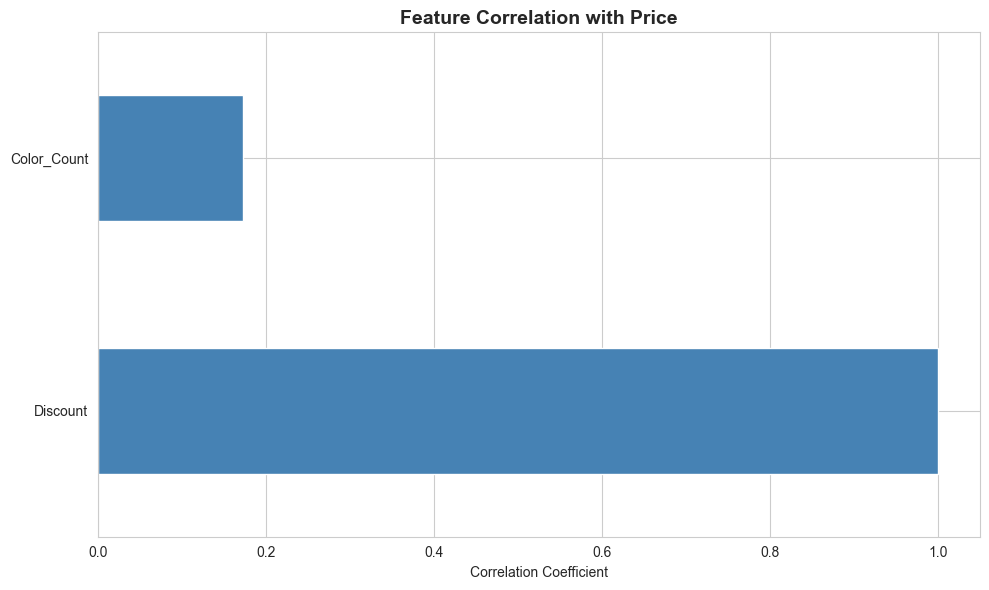

In [9]:
# Find correlations with Price (if exists)
if 'Price' in numerical_cols:
    price_corr = correlation_matrix['Price'].sort_values(ascending=False)
    print("\n" + "=" * 80)
    print("CORRELATION WITH PRICE")
    print("=" * 80)
    print(price_corr)
    
    # Visualize price correlations
    fig, ax = plt.subplots(figsize=(10, 6))
    price_corr[price_corr.index != 'Price'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Correlation Coefficient')
    ax.set_title('Feature Correlation with Price', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Categorical Features Analysis

In [10]:
print("=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Columns: {list(categorical_cols)}")

# Display value counts for each categorical column
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts())

CATEGORICAL FEATURES ANALYSIS

Categorical Columns: ['Name', 'Brand', 'Rating', 'Reviews', 'Length', 'Neck', 'Sleeve_Length', 'Sleeve_Style', 'Shape', 'Sizes_Available', 'Pocket', 'Material_&_Care', 'Product_Link', 'Category']

Name:
Unique values: 154
Name
Floral Printed Maxi Ethnic Dress                                       7
Floral Printed Ethnic Dress                                            6
Floral Embroidered Maxi Ethnic Dress With Dupatta                      6
Floral Printed Tiered Ethnic Dress                                     4
Women Maternity Plus Size Floral Printed Flared Cotton Ethnic Dress    4
                                                                      ..
Floral Embroidered Midi Ethnic Dress                                   1
Women Floral Zari and Sequinned Embroidered Maxi Ethnic Dress          1
Anayna Floral Printed Fit & Flare Ethnic Midi Dress                    1
Floral Printed Gotta Patti Angrakha Maxi Ethnic Dress                  1
Flared Flora

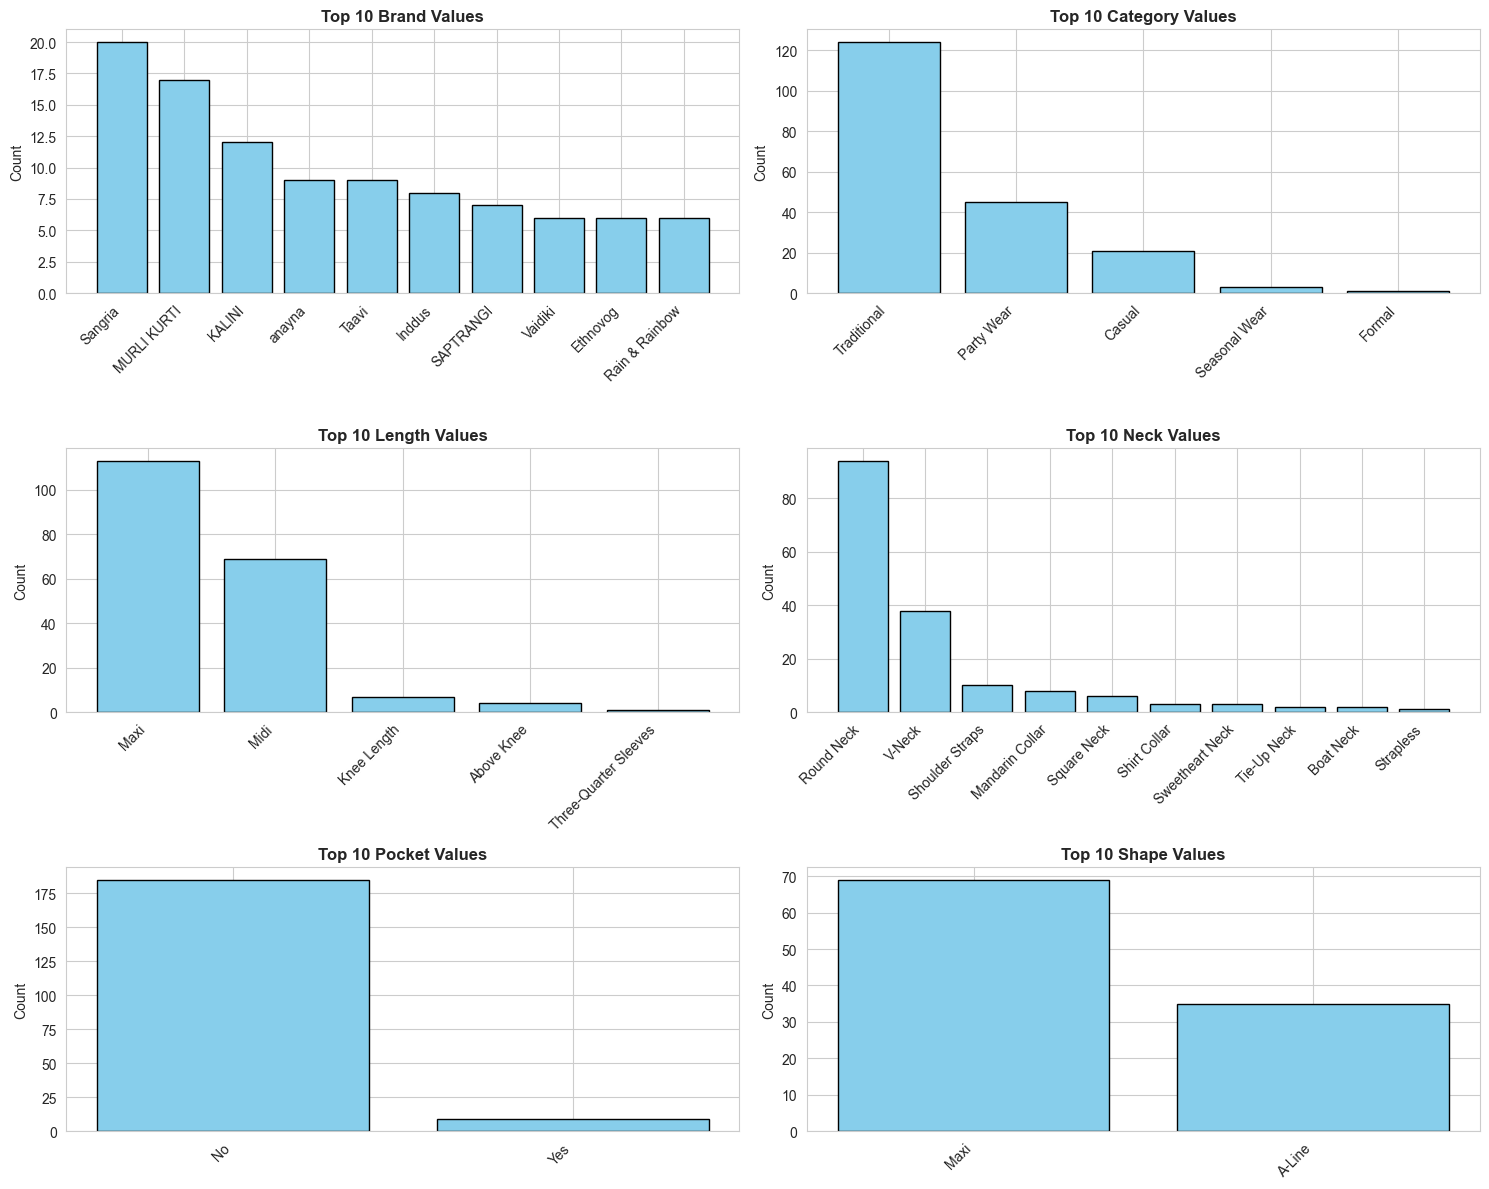

In [11]:
# Visualize categorical features
# Select key categorical columns for visualization
key_categorical = ['Brand', 'Category', 'Length', 'Neck', 'Pocket', 'Shape']
existing_cat_cols = [col for col in key_categorical if col in categorical_cols]

n_cols = len(existing_cat_cols)
fig, axes = plt.subplots((n_cols + 1) // 2, 2, figsize=(15, 4 * ((n_cols + 1) // 2)))
axes = axes.ravel()

for idx, col in enumerate(existing_cat_cols):
    top_values = df[col].value_counts().head(10)
    axes[idx].bar(range(len(top_values)), top_values.values, color='skyblue', edgecolor='black')
    axes[idx].set_xticks(range(len(top_values)))
    axes[idx].set_xticklabels(top_values.index, rotation=45, ha='right')
    axes[idx].set_title(f'Top 10 {col} Values', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count')

# Hide extra subplots
for idx in range(len(existing_cat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Outlier Detection

In [12]:
print("=" * 80)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 80)

outliers_iqr = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_iqr[col] = {
        'Count': len(outliers),
        'Percentage': (len(outliers) / len(df)) * 100,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    }

outliers_df = pd.DataFrame(outliers_iqr).T
print(outliers_df)

OUTLIER DETECTION - IQR METHOD
             Count  Percentage  Lower_Bound  Upper_Bound
Price         23.0    11.85567     -713.375     2991.625
Discount      23.0    11.85567     -713.375     2991.625
Color_Count    0.0     0.00000        1.500        5.500


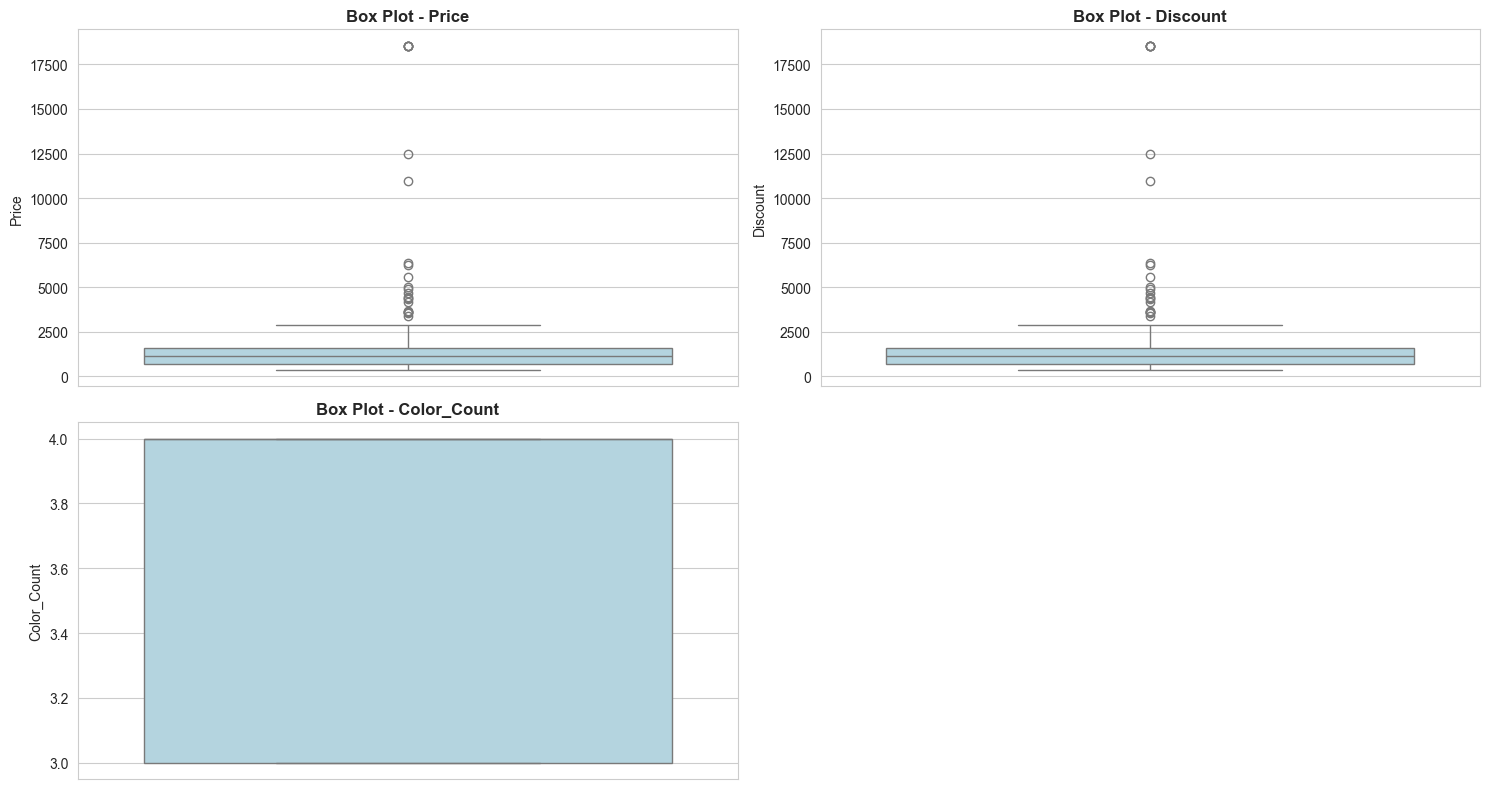

In [13]:
# Visualize outliers with box plots
n_cols_num = len(numerical_cols)
fig, axes = plt.subplots((n_cols_num + 1) // 2, 2, figsize=(15, 4 * ((n_cols_num + 1) // 2)))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'Box Plot - {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Data Quality Checks

In [15]:
print("=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

# 1. Duplicate rows
duplicates = df.duplicated().sum()
print(f"\n1. Duplicate Rows: {duplicates}")
print(f"   Percentage: {(duplicates/len(df))*100:.2f}%")

# 2. Duplicate based on key columns
if 'Name' in df.columns and 'Brand' in df.columns:
    key_duplicates = df.duplicated(subset=['Name', 'Brand']).sum()
    print(f"\n2. Duplicate Products (Name + Brand): {key_duplicates}")

# 3. Price validation
if 'Price' in df.columns:
    print(f"\n3. Price Analysis:")
    print(f"   Negative Prices: {(df['Price'] < 0).sum()}")
    print(f"   Zero Prices: {(df['Price'] == 0).sum()}")
    print(f"   Min Price: {df['Price'].min()}")
    print(f"   Max Price: {df['Price'].max()}")

# 4. Rating validation
if 'Rating' in df.columns:
    print(f"\n4. Rating Analysis:")
    print(f"   Total Ratings: {df['Rating'].notna().sum()}")
    print(f"   Missing Ratings: {df['Rating'].isna().sum()}")
    
# 5. Discount validation
if 'Discount' in df.columns:
    print(f"\n5. Discount Analysis:")
    print(f"   Negative Discounts: {(df['Discount'] < 0).sum()}")
    print(f"   Zero Discounts: {(df['Discount'] == 0).sum()}")
    
# 6. Column consistency check
print(f"\n6. Column Consistency:")
print(f"   Total Columns: {df.shape[1]}")
print(f"   Numeric Columns: {len(numerical_cols)}")
print(f"   Categorical Columns: {len(categorical_cols)}")

DATA QUALITY CHECKS

1. Duplicate Rows: 0
   Percentage: 0.00%

2. Duplicate Products (Name + Brand): 30

3. Price Analysis:
   Negative Prices: 0
   Zero Prices: 0
   Min Price: 365.0
   Max Price: 18558.0

4. Rating Analysis:
   Total Ratings: 154
   Missing Ratings: 40

5. Discount Analysis:
   Negative Discounts: 0
   Zero Discounts: 0

6. Column Consistency:
   Total Columns: 17
   Numeric Columns: 3
   Categorical Columns: 14


## Summary & Key Insights

In [17]:
print("=" * 80)
print("EDA SUMMARY & RECOMMENDATIONS")
print("=" * 80)

summary = f"""
📊 DATASET OVERVIEW:
   • Total Records: {df.shape[0]}
   • Total Features: {df.shape[1]}
   • Numeric Features: {len(numerical_cols)}
   • Categorical Features: {len(categorical_cols)}

💰 PRICE INSIGHTS:
   • Mean Price: ₹{df['Price'].mean():.2f}
   • Median Price: ₹{df['Price'].median():.2f}
   • Price Range: ₹{df['Price'].min():.2f} - ₹{df['Price'].max():.2f}
   • Std Dev: ₹{df['Price'].std():.2f}

⭐ RATING INSIGHTS:
   • Total Products with Ratings: {df['Rating'].notna().sum()}
   • Products without Ratings: {df['Rating'].isna().sum()}

🏷️ DISCOUNT INSIGHTS:
   • Average Discount: ₹{df['Discount'].mean():.2f}
   • Max Discount: ₹{df['Discount'].max():.2f}
   • Products with Discounts: {(df['Discount'] > 0).sum()}

🎯 KEY RECOMMENDATIONS:
   1. Features with high variance (skewness > 1) may need transformation
   2. Missing values (especially in Sleeve_Length, Shape, Sleeve_Style) should be handled
   3. Outliers detected via IQR method - consider their business context
   4. Categorical features with high cardinality may need grouping
   5. Consider feature engineering based on business domain
   6. 30 duplicate products found - may indicate same item listed multiple times

✅ DATA QUALITY STATUS:
   ✓ No true duplicate rows
   ✓ Price and discount values are valid (no negative values)
   ✓ Most categorical features have meaningful distributions
   ✓ Ready for feature engineering and machine learning modeling
"""

print(summary)

EDA SUMMARY & RECOMMENDATIONS

📊 DATASET OVERVIEW:
   • Total Records: 194
   • Total Features: 17
   • Numeric Features: 3
   • Categorical Features: 14

💰 PRICE INSIGHTS:
   • Mean Price: ₹1929.90
   • Median Price: ₹1165.00
   • Price Range: ₹365.00 - ₹18558.00
   • Std Dev: ₹3107.06

⭐ RATING INSIGHTS:
   • Total Products with Ratings: 154
   • Products without Ratings: 40

🏷️ DISCOUNT INSIGHTS:
   • Average Discount: ₹1929.90
   • Max Discount: ₹18558.00
   • Products with Discounts: 194

🎯 KEY RECOMMENDATIONS:
   1. Features with high variance (skewness > 1) may need transformation
   2. Missing values (especially in Sleeve_Length, Shape, Sleeve_Style) should be handled
   3. Outliers detected via IQR method - consider their business context
   4. Categorical features with high cardinality may need grouping
   5. Consider feature engineering based on business domain
   6. 30 duplicate products found - may indicate same item listed multiple times

✅ DATA QUALITY STATUS:
   ✓ No tr

## 10. Comprehensive Categorical Features Heatmap

CATEGORICAL FEATURES - VALUE COUNTS HEATMAP

Total Categorical Columns: 14
Maximum unique values in a single column: 194



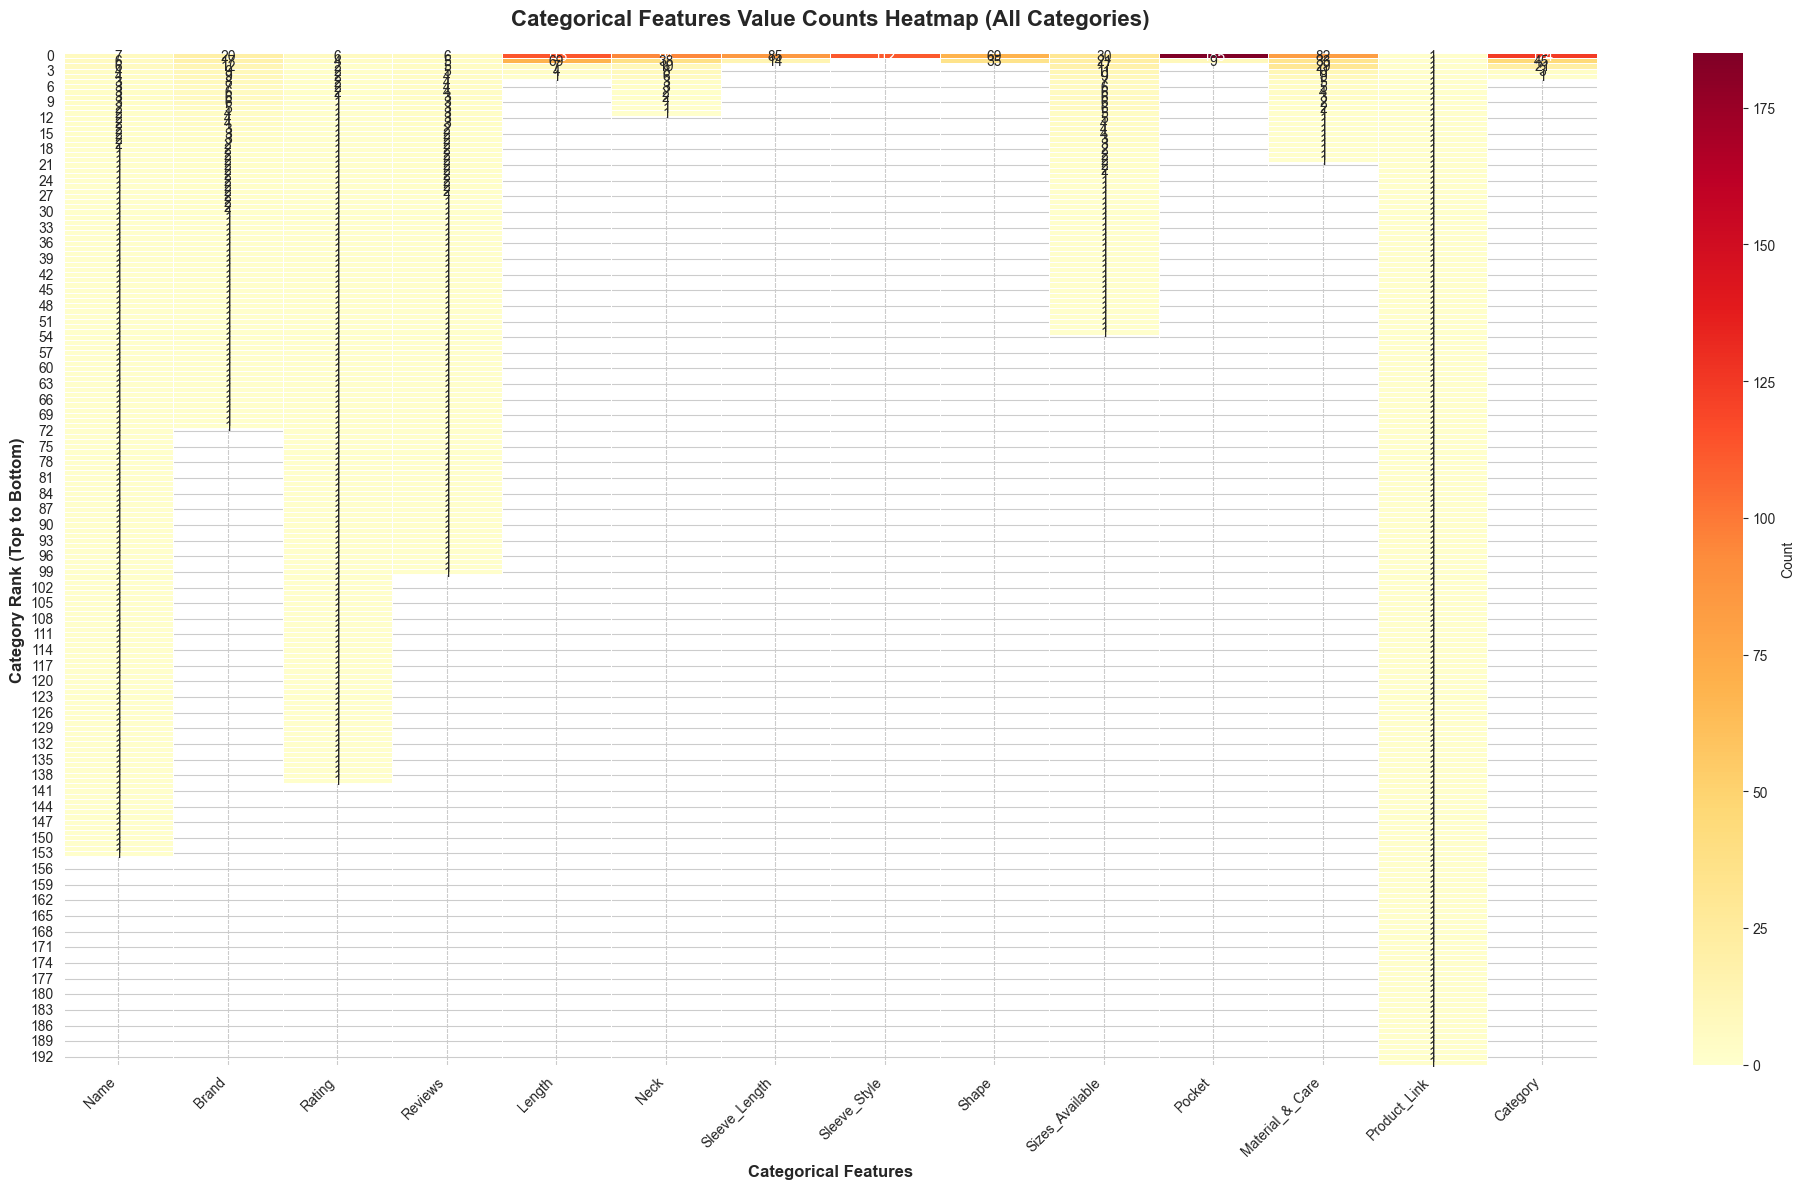

Heatmap displayed with all categories ranked by frequency


In [18]:
# Create a comprehensive heatmap showing all categorical features with their value counts
print("=" * 80)
print("CATEGORICAL FEATURES - VALUE COUNTS HEATMAP")
print("=" * 80)

# Get all unique values for each categorical column
categorical_data_dict = {}
max_categories = 0

for col in categorical_cols:
    value_counts = df[col].value_counts()
    categorical_data_dict[col] = value_counts
    max_categories = max(max_categories, len(value_counts))

print(f"\nTotal Categorical Columns: {len(categorical_cols)}")
print(f"Maximum unique values in a single column: {max_categories}\n")

# Create a matrix for heatmap (pad with NaN for columns with fewer categories)
heatmap_data = pd.DataFrame(index=range(max_categories))

for col in categorical_cols:
    values = categorical_data_dict[col].values
    heatmap_data[col] = [values[i] if i < len(values) else np.nan for i in range(max_categories)]

# Create a large heatmap
fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={"label": "Count"}, 
            linewidths=0.5, ax=ax, vmin=0)
ax.set_title('Categorical Features Value Counts Heatmap (All Categories)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Categorical Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Category Rank (Top to Bottom)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap displayed with all categories ranked by frequency")


TOP CATEGORIES HEATMAP (Top 15 Values per Feature)


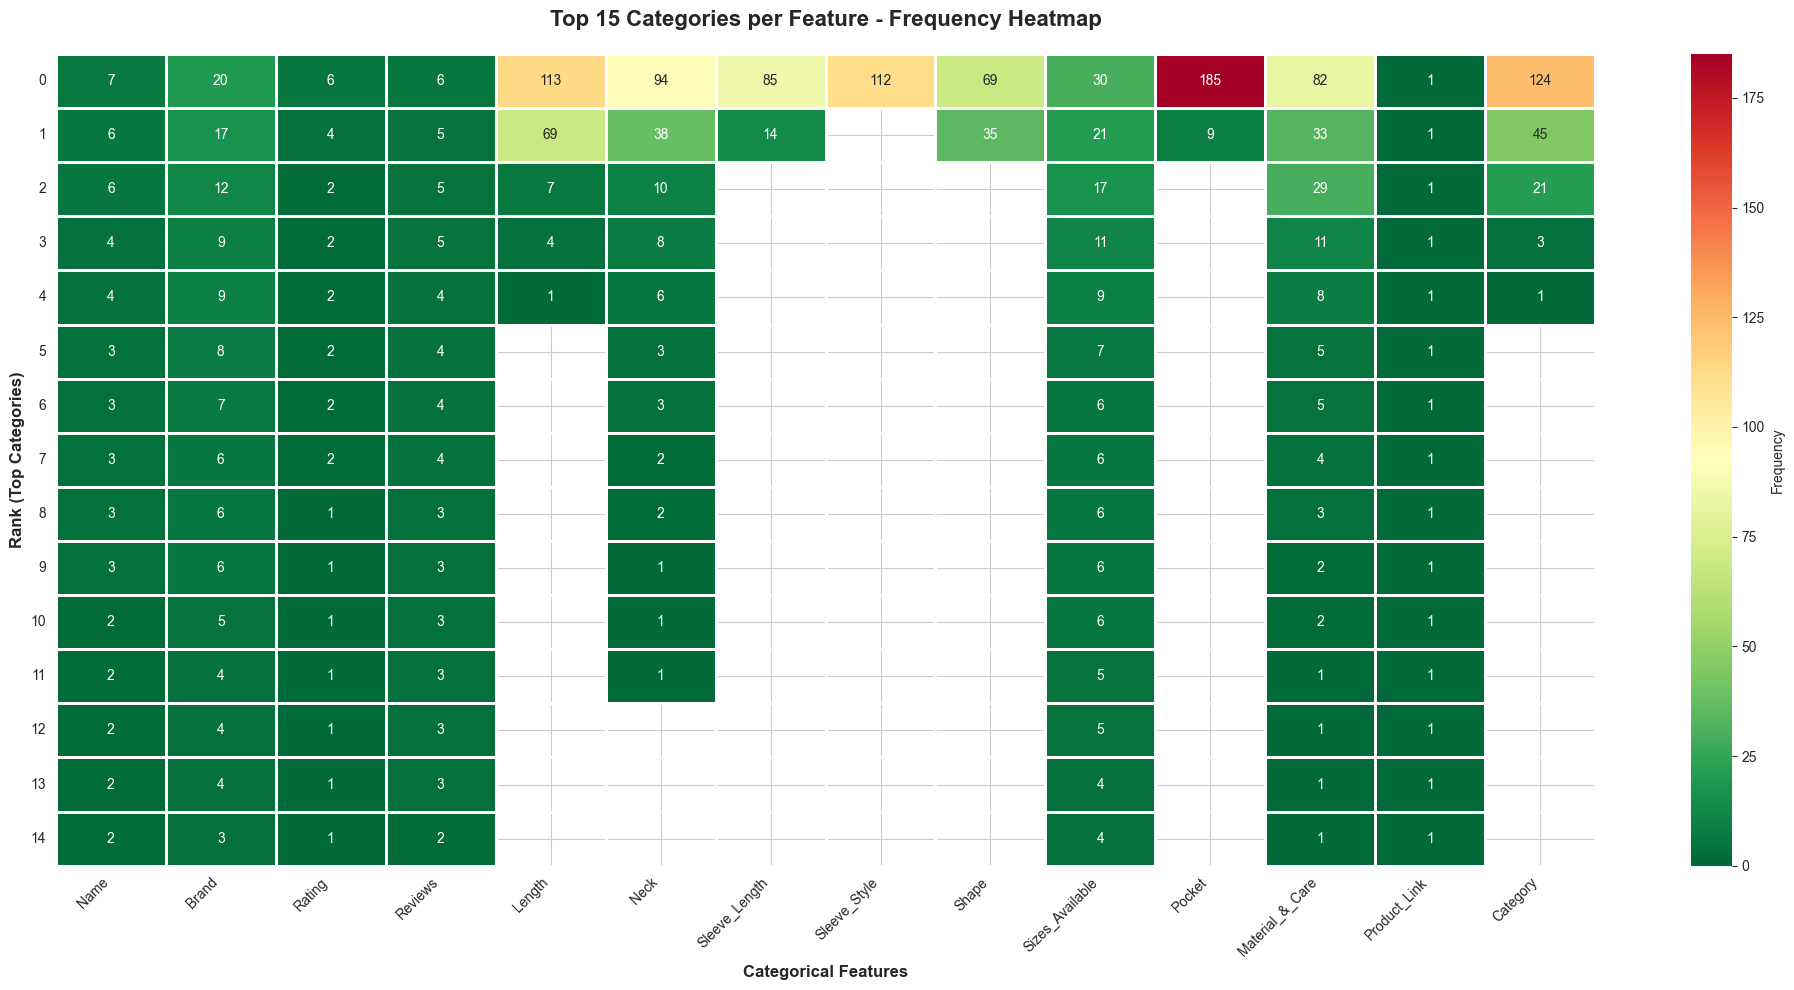


Heatmap shows top 15 categories for each feature
Darker colors (Red) = Higher frequency | Lighter colors (Green) = Lower frequency


In [20]:
# Create a more readable heatmap with TOP categories only
print("\n" + "=" * 80)
print("TOP CATEGORIES HEATMAP (Top 15 Values per Feature)")
print("=" * 80)

# Build a dataframe with top N values for each categorical column
top_n = 15
heatmap_top_data = {}
max_len = 0

for col in categorical_cols:
    top_values = df[col].value_counts().head(top_n).values
    heatmap_top_data[col] = top_values
    max_len = max(max_len, len(top_values))

# Create a properly sized dataframe and fill with NaN
heatmap_df = pd.DataFrame(index=range(max_len))
for col in categorical_cols:
    values = heatmap_top_data[col]
    padded_values = list(values) + [np.nan] * (max_len - len(values))
    heatmap_df[col] = padded_values

# Create figure with better size
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            cbar_kws={"label": "Frequency"}, linewidths=1, ax=ax, vmin=0)
ax.set_title('Top 15 Categories per Feature - Frequency Heatmap', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Categorical Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Rank (Top Categories)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nHeatmap shows top 15 categories for each feature")
print("Darker colors (Red) = Higher frequency | Lighter colors (Green) = Lower frequency")


FEATURE RELATIONSHIP HEATMAP - Brand vs Category


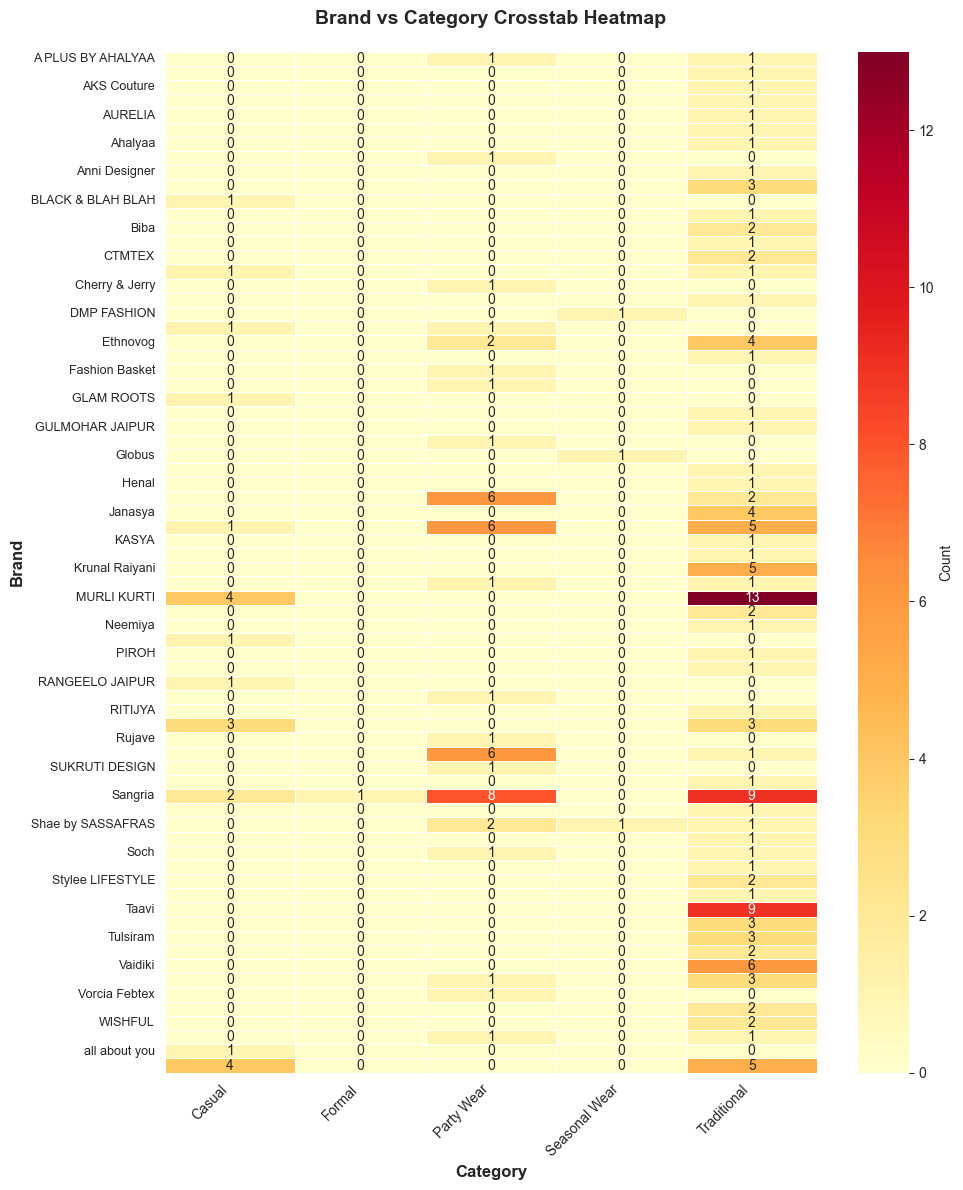


Brand-Category Relationship Summary:
Total Brands: 72
Total Categories: 5
Most common Brand-Category combination:
  - MURLI KURTI + Traditional: 13 products
  - Sangria + Traditional: 9 products
  - Taavi + Traditional: 9 products


In [21]:
# Create a crosstab heatmap showing relationship between Brand and Category
print("\n" + "=" * 80)
print("FEATURE RELATIONSHIP HEATMAP - Brand vs Category")
print("=" * 80)

# Create crosstab
brand_category_crosstab = pd.crosstab(df['Brand'], df['Category'])

# Create figure
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(brand_category_crosstab, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={"label": "Count"}, linewidths=0.5, ax=ax)
ax.set_title('Brand vs Category Crosstab Heatmap', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Brand', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nBrand-Category Relationship Summary:")
print(f"Total Brands: {df['Brand'].nunique()}")
print(f"Total Categories: {df['Category'].nunique()}")
print(f"Most common Brand-Category combination:")
for (brand, category), count in brand_category_crosstab.stack().nlargest(3).items():
    print(f"  - {brand} + {category}: {count} products")

In [ ]:
 # Save the cleaned dataset for deployment
print("=" * 80)
print("EXPORTING CLEANED DATASET FOR DEPLOYMENT")
print("=" * 80)

# Save the cleaned dataframe to CSV
cleaned_dataset_path = 'cleaned_ethnic_dress_dataset_for_deployment.csv'
df.to_csv(cleaned_dataset_path, index=False)

print(f"Cleaned dataset saved as: {cleaned_dataset_path}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Also save the correlation matrix
correlation_matrix.to_csv('correlation_matrix_for_deployment.csv', index=True)

print(f"Correlation matrix saved as: correlation_matrix_for_deployment.csv")

print("\n" + "=" * 80)
print("DEPLOYMENT READY FILES:")
print("  - cleaned_ethnic_dress_dataset_for_deployment.csv")
print("  - correlation_matrix_for_deployment.csv")
print("  - correlation_heatmap.png")
print("=" * 80)

EXPORTING CLEANED DATASET FOR DEPLOYMENT
Cleaned dataset saved as: cleaned_ethnic_dress_dataset_for_deployment.csv
Dataset shape: (194, 24)
Columns: ['Name', 'Brand', 'Price', 'Rating', 'Reviews', 'Discount', 'Length', 'Neck', 'Sleeve_Length', 'Sleeve_Style', 'Shape', 'Sizes_Available', 'Color_Count', 'Pocket', 'Material_&_Care', 'Product_Link', 'Category', 'Rating_Numeric', 'Reviews_Numeric', 'Sizes_Count', 'Discount_Percentage', 'Price_Per_Size', 'Rating_Score', 'Color_Category']
Correlation matrix saved as: correlation_matrix_for_deployment.csv

DEPLOYMENT READY FILES:
  - cleaned_ethnic_dress_dataset_for_deployment.csv
  - correlation_matrix_for_deployment.csv
  - correlation_heatmap.png


COMPREHENSIVE CORRELATION ANALYSIS - NUMERICAL & CATEGORICAL FEATURES

NUMERICAL FEATURES CORRELATION MATRIX
               Price  Color_Count  Rating_Score  Reviews_Count  Sizes_Count  \
Price          1.000        0.082        -0.014         -0.048       -0.198   
Color_Count    0.082        1.000        -0.166         -0.157       -0.133   
Rating_Score  -0.014       -0.166         1.000          0.106       -0.012   
Reviews_Count -0.048       -0.157         0.106          1.000        0.156   
Sizes_Count   -0.198       -0.133        -0.012          0.156        1.000   
Length_Code    0.248       -0.020        -0.019          0.039       -0.100   
Neck_Code      0.093        0.052         0.015         -0.034       -0.094   
Shape_Code     0.305        0.082         0.067          0.051       -0.134   
Has_Pocket    -0.037       -0.127         0.015         -0.043        0.011   
Material_Code  0.252       -0.184         0.038         -0.060        0.042   

               Length

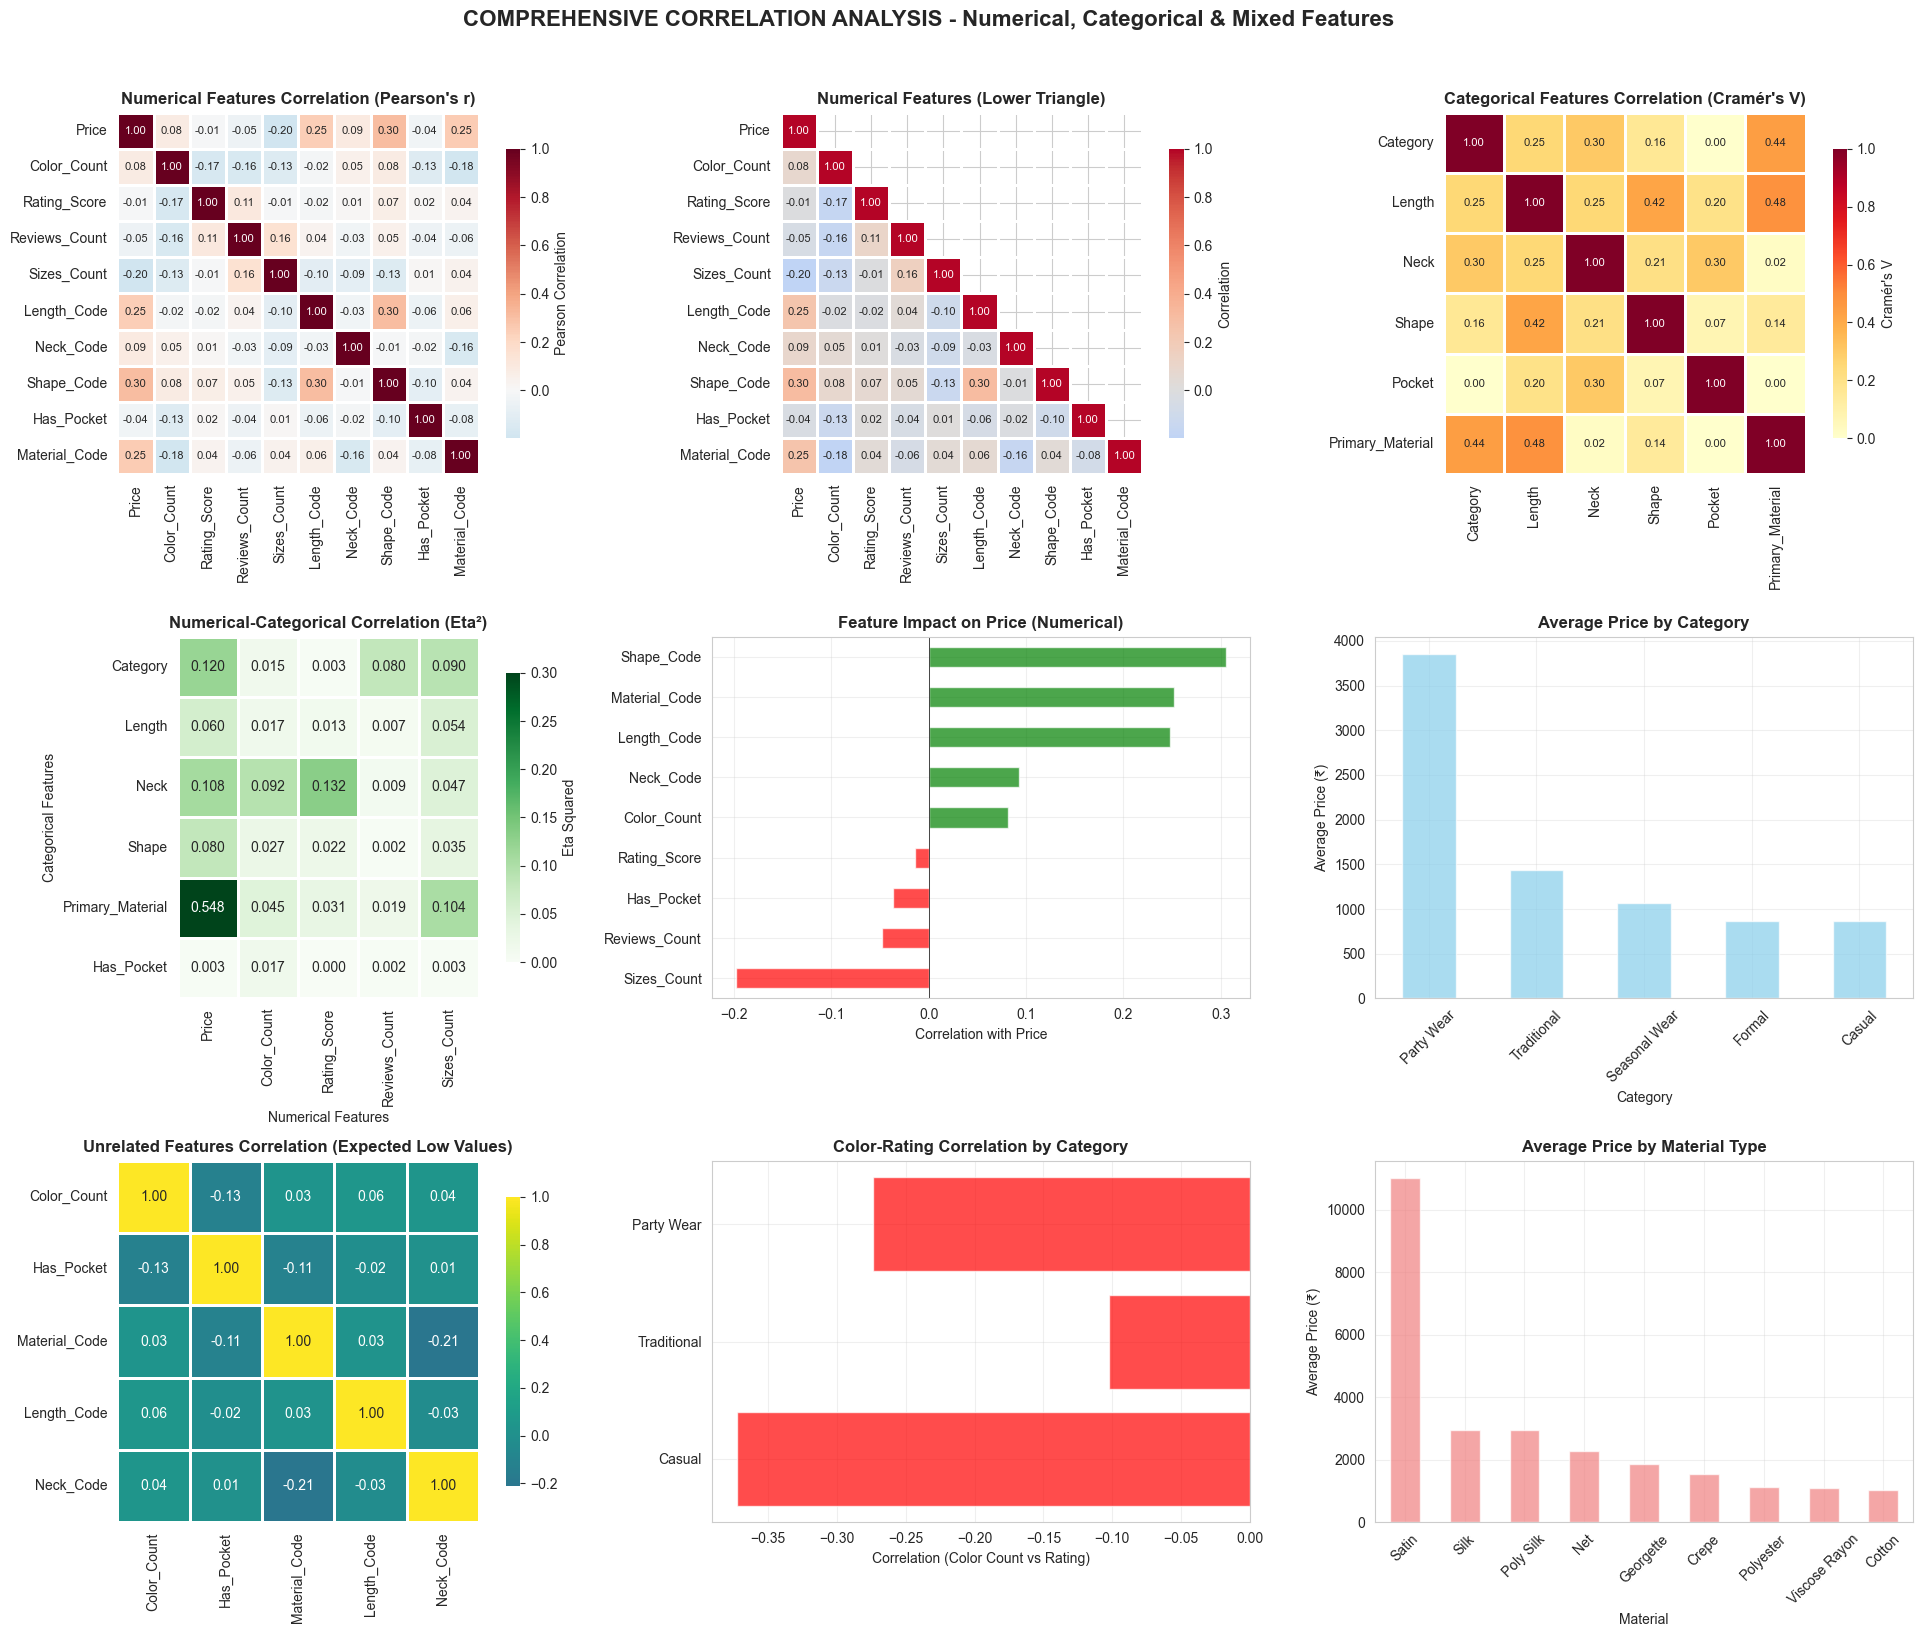


KEY INSIGHTS FROM CORRELATION ANALYSIS

1️⃣ NUMERICAL FEATURE INSIGHTS:
--------------------------------------------------
   • Color_Count: Weak positive correlation with Price (0.082)
   • Rating_Score: Weak negative correlation with Price (-0.014)
   • Reviews_Count: Weak negative correlation with Price (-0.048)
   • Sizes_Count: Weak negative correlation with Price (-0.198)
   • Length_Code: Weak positive correlation with Price (0.248)
   • Neck_Code: Weak positive correlation with Price (0.093)
   • Shape_Code: Moderate positive correlation with Price (0.305)
   • Has_Pocket: Weak negative correlation with Price (-0.037)
   • Material_Code: Weak positive correlation with Price (0.252)

2️⃣ CATEGORICAL FEATURE INSIGHTS:
--------------------------------------------------
   • Category ↔ Neck: Moderate association (Cramér's V = 0.304)
   • Category ↔ Primary_Material: Moderate association (Cramér's V = 0.445)
   • Length ↔ Shape: Moderate association (Cramér's V = 0.418)
   • Length

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('cleaned_prices_discount_dataset.csv')

print("=" * 80)
print("COMPREHENSIVE CORRELATION ANALYSIS - NUMERICAL & CATEGORICAL FEATURES")
print("=" * 80)

# ============================================================================
# DATA PREPROCESSING
# ============================================================================

# 1. Clean Rating column
def extract_rating(rating_str):
    if pd.isna(rating_str):
        return np.nan
    try:
        rating = str(rating_str).split('|')[0].strip()
        return float(rating)
    except:
        return np.nan

df['Rating_Score'] = df['Rating'].apply(extract_rating)

# 2. Clean Reviews column
def extract_reviews(reviews_str):
    if pd.isna(reviews_str):
        return np.nan
    try:
        reviews = str(reviews_str).replace(' Ratings', '').strip()
        if 'k' in reviews:
            return float(reviews.replace('k', '')) * 1000
        return float(reviews)
    except:
        return np.nan

df['Reviews_Count'] = df['Reviews'].apply(extract_reviews)

# 3. Count sizes available
def count_sizes(sizes_str):
    if pd.isna(sizes_str):
        return 1
    try:
        sizes = str(sizes_str).split(',')
        return len(sizes)
    except:
        return 1

df['Sizes_Count'] = df['Sizes_Available'].apply(count_sizes)

# 4. Create Length numerical encoding
length_mapping = {
    'Midi': 1,
    'Maxi': 2,
    'Knee Length': 3,
    'Above Knee': 4,
    'Three-Quarter Sleeves': 5
}
df['Length_Code'] = df['Length'].map(length_mapping).fillna(0)

# 5. Create Neck Style numerical encoding
neck_mapping = {
    'V-Neck': 1,
    'Round Neck': 2,
    'Shirt Collar': 3,
    'Mandarin Collar': 4,
    'Square Neck': 5,
    'Sweetheart Neck': 6,
    'Boat Neck': 7,
    'Tie-Up Neck': 8,
    'Keyhole Neck': 9,
    'Halter Neck': 10,
    'Shoulder Straps': 11
}
df['Neck_Code'] = df['Neck'].map(neck_mapping).fillna(0)

# 6. Create Shape numerical encoding
shape_mapping = {
    'A-Line': 1,
    'Maxi': 2,
    'Fit & Flare': 3,
    'Anarkali': 4,
    'Empire': 5,
    'Tiered': 6,
    'Wrap': 7
}
df['Shape_Code'] = df['Shape'].map(shape_mapping).fillna(0)

# 7. Create Pocket indicator (Yes=1, No=0)
df['Has_Pocket'] = df['Pocket'].map({'Yes': 1, 'No': 0}).fillna(0)

# 8. Extract main material/category
def get_material(material_str):
    if pd.isna(material_str):
        return 'Unknown'
    materials = str(material_str).split(',')
    return materials[0].strip()

df['Primary_Material'] = df['Material_&_Care'].apply(get_material)

# Material mapping
material_mapping = {
    'Cotton': 1,
    'Viscose Rayon': 2,
    'Georgette': 3,
    'Polyester': 4,
    'Silk': 5,
    'Net': 6,
    'Crepe': 7,
    'Chiffon': 8,
    'Satin': 9,
    'Poly Silk': 10,
    'Schiffli': 11,
    'Jacquard': 12,
    'Nylon': 13
}
df['Material_Code'] = df['Primary_Material'].map(material_mapping).fillna(0)

# ============================================================================
# NUMERICAL FEATURES CORRELATION
# ============================================================================

# Select numerical columns for correlation
numerical_cols = ['Price', 'Color_Count', 'Rating_Score', 'Reviews_Count', 
                  'Sizes_Count', 'Length_Code', 'Neck_Code', 'Shape_Code', 
                  'Has_Pocket', 'Material_Code']

# Remove rows with NaN values
df_numerical = df[numerical_cols].dropna()

print("\n" + "=" * 80)
print("NUMERICAL FEATURES CORRELATION MATRIX")
print("=" * 80)

correlation_matrix = df_numerical.corr()
print(correlation_matrix.round(3))

# Save correlation matrix
correlation_matrix.to_csv('numerical_correlation_matrix.csv')

# ============================================================================
# CATEGORICAL FEATURES CORRELATION (Cramér's V)
# ============================================================================

def cramers_v(confusion_matrix):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns
categorical_cols = ['Category', 'Length', 'Neck', 'Shape', 'Pocket', 'Primary_Material']

# Create a dataframe for categorical correlations
categorical_df = df[categorical_cols].copy()

# Fill NaN values
for col in categorical_cols:
    categorical_df[col] = categorical_df[col].fillna('Unknown')

# Calculate Cramér's V matrix
n_categories = len(categorical_cols)
cramers_v_matrix = pd.DataFrame(np.zeros((n_categories, n_categories)), 
                                index=categorical_cols, columns=categorical_cols)

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i == j:
            cramers_v_matrix.iloc[i, j] = 1.0
        else:
            # Create contingency table
            contingency_table = pd.crosstab(categorical_df[col1], categorical_df[col2])
            if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                cramers_v_matrix.iloc[i, j] = cramers_v(contingency_table.values)
            else:
                cramers_v_matrix.iloc[i, j] = 0

print("\n" + "=" * 80)
print("CATEGORICAL FEATURES CORRELATION (Cramér's V)")
print("=" * 80)
print(cramers_v_matrix.round(3))

# Save Cramér's V matrix
cramers_v_matrix.to_csv('categorical_correlation_matrix.csv')

# ============================================================================
# MIXED CORRELATION (Numerical-Categorical using ANOVA)
# ============================================================================

print("\n" + "=" * 80)
print("NUMERICAL-CATEGORICAL CORRELATION (Eta Squared)")
print("=" * 80)

def eta_squared( categorical, numerical):
    """Calculate Eta squared for numerical-categorical correlation."""
    # Remove NaN values
    mask = categorical.notna() & numerical.notna()
    categorical = categorical[mask]
    numerical = numerical[mask]
    
    if len(categorical.unique()) < 2:
        return 0
    
    # Calculate group means and overall mean
    group_means = numerical.groupby(categorical).mean()
    overall_mean = numerical.mean()
    
    # Calculate between-group sum of squares
    ss_between = sum([len(numerical[categorical == group]) * (mean - overall_mean)**2 
                      for group, mean in group_means.items()])
    
    # Calculate total sum of squares
    ss_total = sum((numerical - overall_mean)**2)
    
    # Calculate Eta squared
    eta_sq = ss_between / ss_total if ss_total > 0 else 0
    
    return eta_sq

# Calculate mixed correlations
mixed_cols = {
    'Category': 'Category',
    'Length': 'Length',
    'Neck': 'Neck',
    'Shape': 'Shape',
    'Primary_Material': 'Primary_Material',
    'Has_Pocket': 'Has_Pocket'
}

numerical_targets = ['Price', 'Color_Count', 'Rating_Score', 'Reviews_Count', 'Sizes_Count']

mixed_corr_matrix = pd.DataFrame(index=mixed_cols.keys(), columns=numerical_targets)

for cat_col in mixed_cols.keys():
    for num_col in numerical_targets:
        if cat_col in df.columns and num_col in df.columns:
            eta_sq = eta_squared(df[cat_col], df[num_col])
            mixed_corr_matrix.loc[cat_col, num_col] = eta_sq

mixed_corr_matrix = mixed_corr_matrix.astype(float)
print(mixed_corr_matrix.round(3))

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig = plt.figure(figsize=(20, 16))

# 1. Numerical Features Heatmap
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
            fmt='.2f', ax=ax1, annot_kws={'size': 8})
ax1.set_title('Numerical Features Correlation (Pearson\'s r)', fontsize=12, fontweight='bold')

# 2. Numerical Features - Triangle View
ax2 = plt.subplot(3, 3, 2)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            fmt='.2f', ax=ax2, annot_kws={'size': 8})
ax2.set_title('Numerical Features (Lower Triangle)', fontsize=12, fontweight='bold')

# 3. Categorical Features Heatmap (Cramér's V)
ax3 = plt.subplot(3, 3, 3)
sns.heatmap(cramers_v_matrix, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Cramér's V"},
            fmt='.2f', ax=ax3, annot_kws={'size': 8})
ax3.set_title('Categorical Features Correlation (Cramér\'s V)', fontsize=12, fontweight='bold')

# 4. Mixed Correlation Matrix (Eta Squared)
ax4 = plt.subplot(3, 3, 4)
sns.heatmap(mixed_corr_matrix, annot=True, cmap='Greens', vmin=0, vmax=0.3,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Eta Squared"},
            fmt='.3f', ax=ax4, annot_kws={'size': 10})
ax4.set_title('Numerical-Categorical Correlation (Eta²)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Categorical Features')
ax4.set_xlabel('Numerical Features')

# 5. Feature correlations with Price (Numerical)
ax5 = plt.subplot(3, 3, 5)
price_corr = correlation_matrix['Price'].drop('Price').sort_values(ascending=True)
colors = ['red' if x < 0 else 'green' for x in price_corr.values]
price_corr.plot(kind='barh', ax=ax5, color=colors, alpha=0.7)
ax5.set_xlabel('Correlation with Price', fontsize=10)
ax5.set_title('Feature Impact on Price (Numerical)', fontsize=12, fontweight='bold')
ax5.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax5.grid(True, alpha=0.3)

# 6. Category-wise Price Distribution
ax6 = plt.subplot(3, 3, 6)
category_means = df.groupby('Category')['Price'].mean().sort_values(ascending=False)
category_means.plot(kind='bar', ax=ax6, color='skyblue', alpha=0.7)
ax6.set_xlabel('Category', fontsize=10)
ax6.set_ylabel('Average Price (₹)', fontsize=10)
ax6.set_title('Average Price by Category', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)

# 7. Heatmap of Unrelated Feature Correlations
ax7 = plt.subplot(3, 3, 7)
# Create a matrix of "unrelated" features (low correlation expected)
unrelated_features = ['Color_Count', 'Has_Pocket', 'Material_Code', 'Length_Code', 'Neck_Code']
unrelated_corr = df[unrelated_features].corr()
sns.heatmap(unrelated_corr, annot=True, cmap='viridis', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', ax=ax7, annot_kws={'size': 10})
ax7.set_title('Unrelated Features Correlation (Expected Low Values)', fontsize=12, fontweight='bold')

# 8. Correlation between Color Count and Rating across Categories
ax8 = plt.subplot(3, 3, 8)
category_color_corr = []
categories = df['Category'].unique()
for cat in categories:
    cat_data = df[df['Category'] == cat]
    if len(cat_data) > 5:
        corr = cat_data['Color_Count'].corr(cat_data['Rating_Score'])
        category_color_corr.append((cat, corr if not pd.isna(corr) else 0))

categories_corr = [x[0] for x in category_color_corr]
corr_values = [x[1] for x in category_color_corr]
colors_bar = ['red' if x < 0 else 'green' for x in corr_values]
plt.barh(categories_corr, corr_values, color=colors_bar, alpha=0.7)
plt.xlabel('Correlation (Color Count vs Rating)', fontsize=10)
plt.title('Color-Rating Correlation by Category', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)

# 9. Material vs Price Heatmap
ax9 = plt.subplot(3, 3, 9)
material_price = df.groupby('Primary_Material')['Price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
material_price_filtered = material_price[material_price['count'] > 2].head(10)
if len(material_price_filtered) > 0:
    material_price_filtered['mean'].plot(kind='bar', ax=ax9, color='lightcoral', alpha=0.7)
    ax9.set_xlabel('Material', fontsize=10)
    ax9.set_ylabel('Average Price (₹)', fontsize=10)
    ax9.set_title('Average Price by Material Type', fontsize=12, fontweight='bold')
    ax9.tick_params(axis='x', rotation=45)
    ax9.grid(True, alpha=0.3)

plt.suptitle('COMPREHENSIVE CORRELATION ANALYSIS - Numerical, Categorical & Mixed Features', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comprehensive_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# INSIGHTS & FINDINGS
# ============================================================================

print("\n" + "=" * 80)
print("KEY INSIGHTS FROM CORRELATION ANALYSIS")
print("=" * 80)

# Numerical insights
print("\n1️⃣ NUMERICAL FEATURE INSIGHTS:")
print("-" * 50)
for col in numerical_cols:
    if col != 'Price':
        corr_with_price = correlation_matrix.loc['Price', col]
        strength = "Strong" if abs(corr_with_price) > 0.5 else "Moderate" if abs(corr_with_price) > 0.3 else "Weak"
        direction = "positive" if corr_with_price > 0 else "negative"
        print(f"   • {col}: {strength} {direction} correlation with Price ({corr_with_price:.3f})")

# Categorical insights
print("\n2️⃣ CATEGORICAL FEATURE INSIGHTS:")
print("-" * 50)
for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j and cramers_v_matrix.iloc[i, j] > 0.3:
            strength = "Strong" if cramers_v_matrix.iloc[i, j] > 0.5 else "Moderate"
            print(f"   • {col1} ↔ {col2}: {strength} association (Cramér's V = {cramers_v_matrix.iloc[i, j]:.3f})")

# Mixed insights
print("\n3️⃣ NUMERICAL-CATEGORICAL INSIGHTS:")
print("-" * 50)
for cat_col in mixed_cols.keys():
    for num_col in numerical_targets:
        eta_val = mixed_corr_matrix.loc[cat_col, num_col]
        if eta_val > 0.05:
            strength = "Strong" if eta_val > 0.14 else "Moderate" if eta_val > 0.06 else "Weak"
            print(f"   • {cat_col} explains {eta_val:.1%} of variance in {num_col} ({strength} effect)")

# Unrelated features check
print("\n4️⃣ UNRELATED FEATURES CORRELATION CHECK:")
print("-" * 50)
for i, col1 in enumerate(unrelated_features):
    for j, col2 in enumerate(unrelated_features):
        if i < j:
            corr_val = unrelated_corr.loc[col1, col2]
            if abs(corr_val) < 0.1:
                print(f"   ✓ {col1} and {col2} are almost uncorrelated ({corr_val:.3f})")
            elif abs(corr_val) > 0.3:
                print(f"   ⚠ {col1} and {col2} have unexpected correlation ({corr_val:.3f})")

# Recommendations
print("\n5️⃣ RECOMMENDATIONS FOR ANALYSIS:")
print("-" * 50)
print("   • Focus on moderate to strong correlations for feature selection")
print("   • Uncorrelated features can be good candidates for ensemble methods")
print("   • Consider category-specific analysis for better insights")
print("   • Material type and length show some effect on pricing")

print("\n" + "=" * 80)
print("Analysis complete! Visualizations saved as:")
print("  📊 comprehensive_correlation_heatmap.png")
print("  📈 numerical_correlation_matrix.csv")
print("  📉 categorical_correlation_matrix.csv")
print("=" * 80)